In [1]:
import torch
import torch.nn as nn

from data.transform import VideoTrainTransform,VideoValTransform
from data.video_dataset import create_datasets
from data.video_dataloader import load_dataloader

from models import get_model

from pathlib import Path

from utils.helper_functions import plot_images

c:\Users\javie\Documents\William V\paper\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root=Path.cwd()
dataset_dir=root/"datasets"/"r3d_dataset_tensor"

tensor_dir=dataset_dir/"alejandro"/"actividad_extra"/"video_1.pt"

In [3]:
frame_tensors=torch.load(str(tensor_dir))

frame_tensors.shape

torch.Size([16, 3, 112, 112])

In [6]:
frame_tensors/255.0

tensor([[[[0.7686, 0.7686, 0.7647,  ..., 0.6902, 0.6941, 0.6941],
          [0.7725, 0.7686, 0.7686,  ..., 0.6902, 0.6941, 0.6941],
          [0.7804, 0.7725, 0.7686,  ..., 0.6902, 0.6902, 0.6902],
          ...,
          [0.1255, 0.1255, 0.1255,  ..., 0.6745, 0.6431, 0.6118],
          [0.1255, 0.1294, 0.1255,  ..., 0.6431, 0.6157, 0.6078],
          [0.1255, 0.1294, 0.1294,  ..., 0.6039, 0.5529, 0.5765]],

         [[0.7569, 0.7569, 0.7569,  ..., 0.6941, 0.6980, 0.6941],
          [0.7608, 0.7569, 0.7569,  ..., 0.6941, 0.6980, 0.6980],
          [0.7686, 0.7608, 0.7569,  ..., 0.6941, 0.6980, 0.6941],
          ...,
          [0.1216, 0.1216, 0.1216,  ..., 0.6431, 0.6118, 0.5804],
          [0.1216, 0.1216, 0.1216,  ..., 0.6118, 0.5843, 0.5765],
          [0.1255, 0.1255, 0.1255,  ..., 0.5725, 0.5216, 0.5451]],

         [[0.7686, 0.7725, 0.7686,  ..., 0.7137, 0.7176, 0.7176],
          [0.7765, 0.7725, 0.7686,  ..., 0.7137, 0.7176, 0.7176],
          [0.7843, 0.7765, 0.7686,  ..., 0

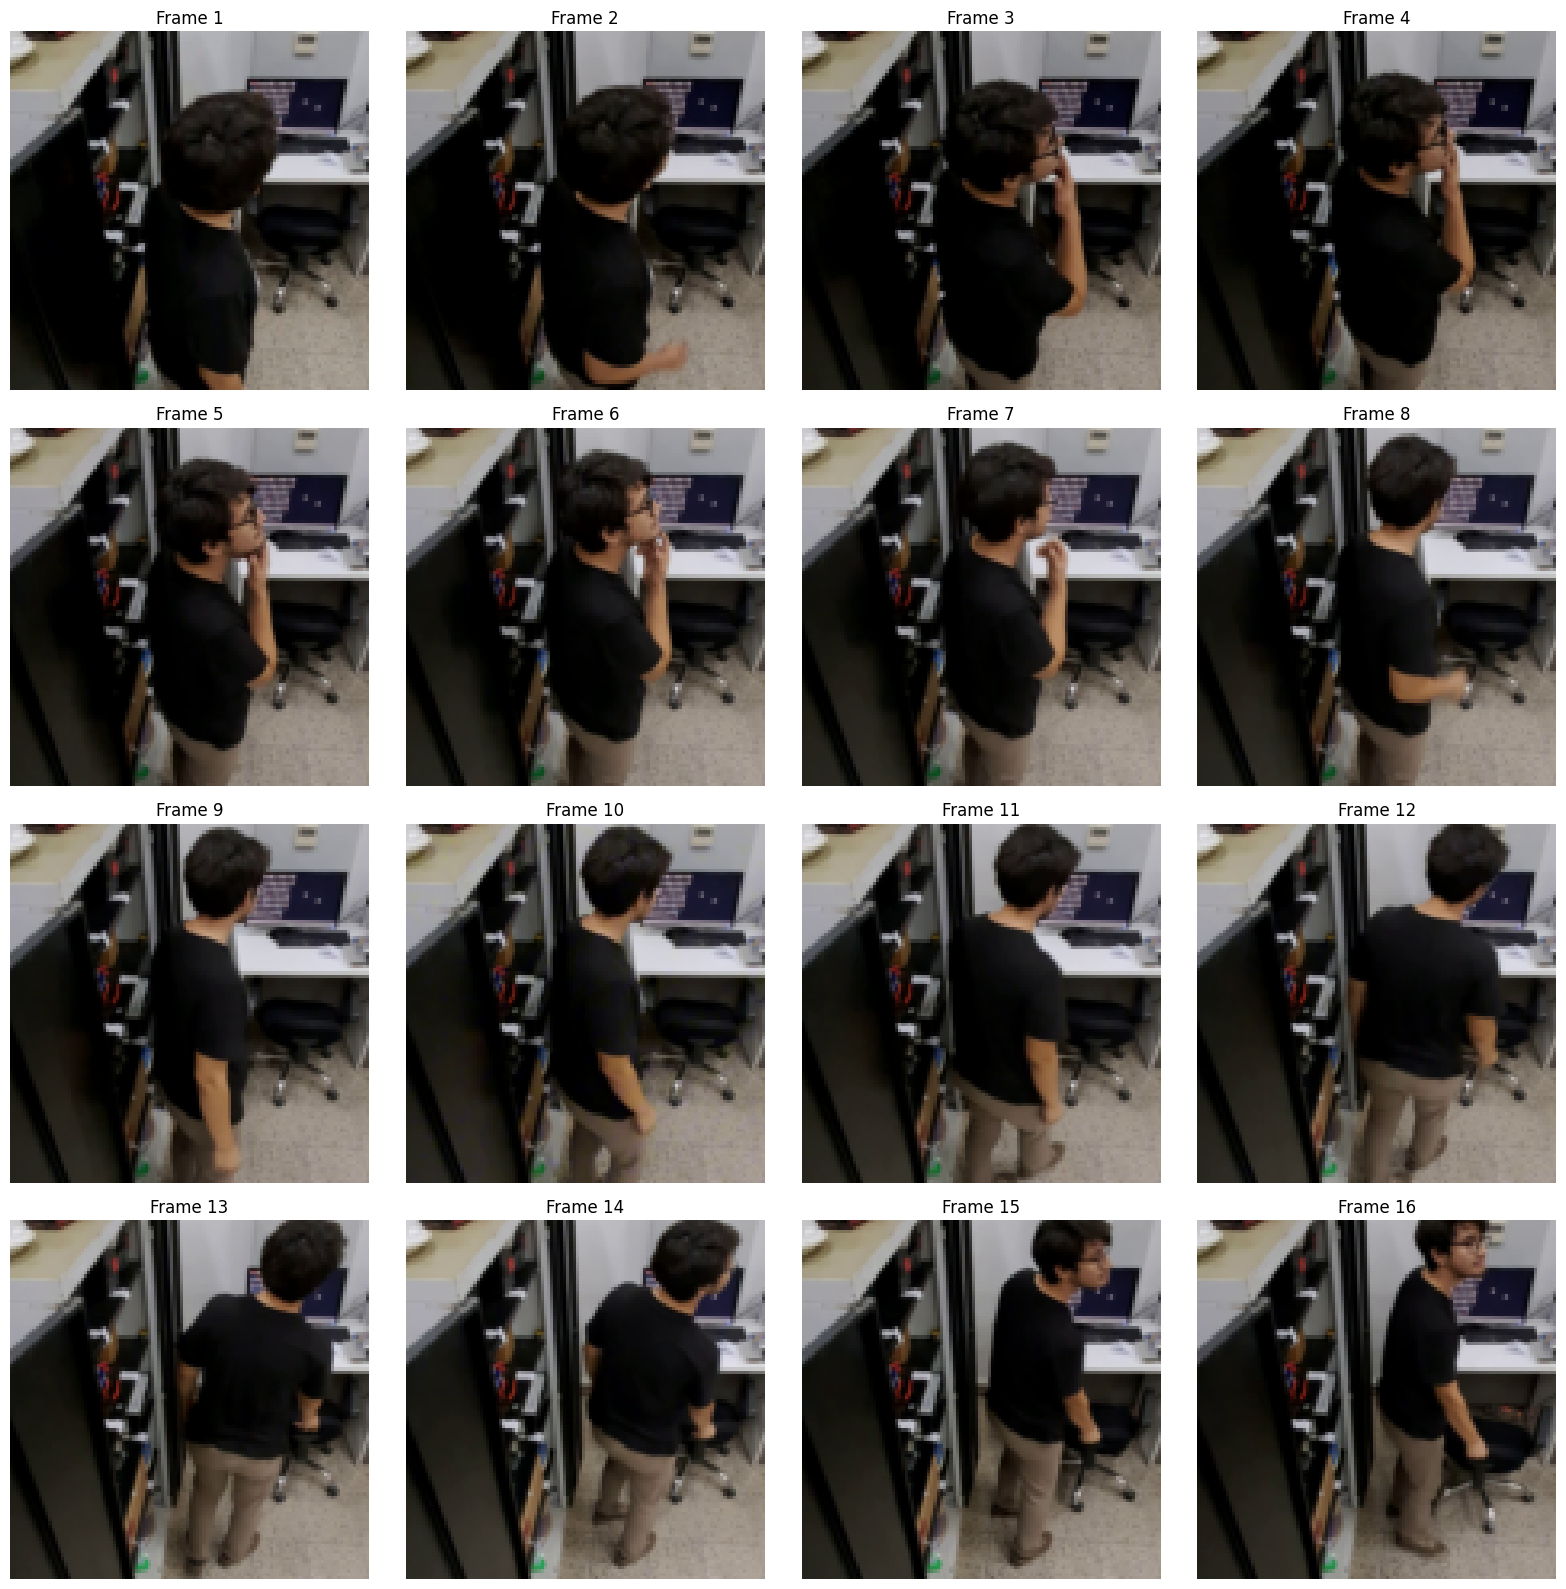

In [4]:
plot_images(frame_tensors.permute(0,2,3,1),4,4)

In [9]:
model = get_model(model=4,
                  num_classes=5,
                  phase=2)

model.__class__.__name__

'SwinTransformer3d'

In [10]:
model

SwinTransformer3d(
  (patch_embed): PatchEmbed3d(
    (proj): Conv3d(3, 96, kernel_size=(2, 4, 4), stride=(2, 4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (features): Sequential(
    (0): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention3d(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
     

In [4]:
train_dataset,val_dataset=create_datasets(train_path=dataset_dir/"train",
                val_path=dataset_dir/"val",
                num_frames=16,
                strategy="uniform",
                train_transform=VideoTrainTransform(model=model),
                val_transform=VideoValTransform(model=model)
                )

In [5]:
train_dataloader=load_dataloader(train_dataset=train_dataset,
                val_dataset=val_dataset,
                batch_size=2,
                is_train_loader=True,
                num_workers=0,
                seed=42)

In [6]:
x,y=next(iter(train_dataloader))

In [7]:
x.shape

torch.Size([2, 16, 3, 64, 64])

In [20]:
from utils.helper_functions import plot_images

In [21]:
frames=x[0].squeeze(dim=0)
frames.shape

torch.Size([16, 3, 96, 96])

In [22]:
frames.permute(0,2,3,1).shape

torch.Size([16, 96, 96, 3])

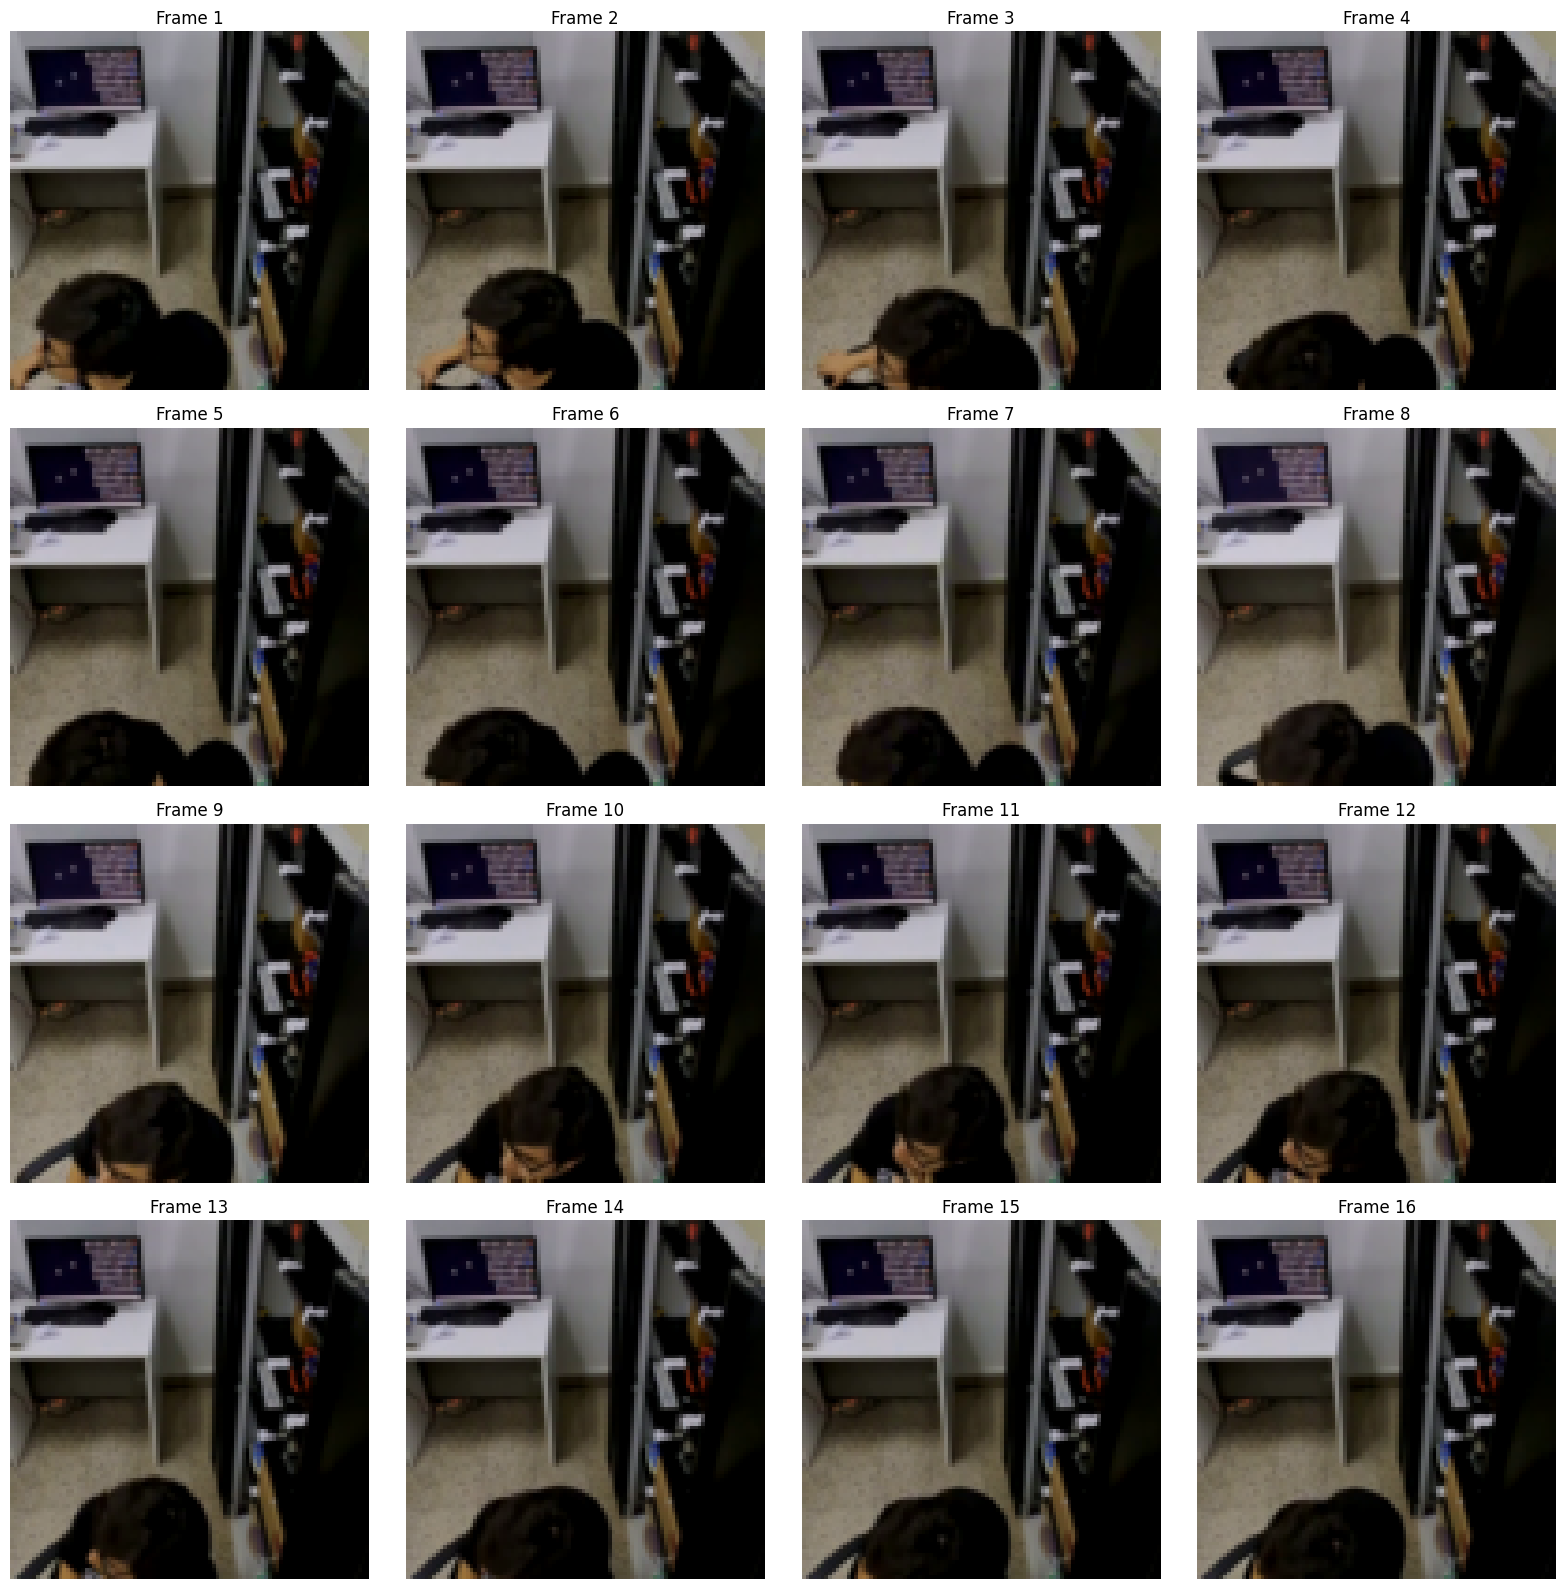

In [23]:
plot_images(frames.permute(0,2,3,1),4,4)

In [25]:
x.shape

torch.Size([2, 16, 3, 96, 96])

In [8]:
dummy_tensor=torch.randn((1,3,16,224,224))

dummy_tensor_2=torch.randn((1,3,16,112,112))

dummy_tensor_3=torch.randn((1,16,3,224,224))

In [9]:
model(dummy_tensor_3)

ImageClassifierOutput(loss=None, logits=tensor([[-0.6427, -0.4187,  0.1992,  0.8309,  0.0740]],
       grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [11]:
from torchvision.models.video import s3d

In [12]:
s3d_model=s3d()

In [14]:
s3d_model

S3D(
  (features): Sequential(
    (0): TemporalSeparableConv(
      (0): Conv3dNormActivation(
        (0): Conv3d(3, 64, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        (1): BatchNorm3d(64, eps=0.001, momentum=0.001, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): Conv3dNormActivation(
        (0): Conv3d(64, 64, kernel_size=(7, 1, 1), stride=(2, 1, 1), padding=(3, 0, 0), bias=False)
        (1): BatchNorm3d(64, eps=0.001, momentum=0.001, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1), dilation=1, ceil_mode=False)
    (2): Conv3dNormActivation(
      (0): Conv3d(64, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
      (1): BatchNorm3d(64, eps=0.001, momentum=0.001, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (3): TemporalSeparableConv(
      (0): Conv3d

In [23]:

for name, children in s3d_model.named_children():
    if name == "features":
        for param in children[14:].parameters():
            param.requires_grad=True
    elif name == "classifier":
        print("a")
        for param in children.parameters():
            param.requires_grad=True

a
